In [1]:
%pip install --upgrade pip
%pip install pandas pyarrow numpy matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib as plt
import warnings
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importing clean dataset
df_listings = pd.read_parquet('../data/clean_listings.parquet', engine='auto')
#print(df_listings)
print(len(df_listings.columns))
df_listings.info()

39
<class 'pandas.DataFrame'>
Index: 68699 entries, 0 to 95896
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   listing_id               68683 non-null  Int64  
 1   listing_type             68699 non-null  str    
 2   room_type                68699 non-null  str    
 3   cover_photo_url          68699 non-null  str    
 4   photos_count             68699 non-null  Int64  
 5   host_id                  68699 non-null  str    
 6   superhost                68699 non-null  boolean
 7   guests                   68699 non-null  Int64  
 8   bedrooms                 68699 non-null  Int64  
 9   beds                     68699 non-null  float64
 10  baths                    68699 non-null  float64
 11  registration             68474 non-null  boolean
 12  amenities                68699 non-null  str    
 13  amenities_count          68699 non-null  int64  
 14  instant_book             14283 non-

In [3]:
# QUEDARSE SOLO CON NUMÉRICAS LIMPIAS
l = df_listings.select_dtypes(include="number").copy()

# FORZAR CONVERSIÓN (por seguridad)
l = l.apply(pd.to_numeric, errors="coerce")

# QUITAR NULOS CREADOS POR CONVERSIÓN
l = l.dropna()

print(l)



       listing_id  photos_count  guests  bedrooms  beds  baths  \
0          121902            77       6         3   4.0    1.0   
2          805361            34       5         2   4.0    1.0   
3          853827            70      16        12  15.0    6.0   
5          997955            42       6         2   3.0    1.5   
6         1149100            55       6         3   3.0    2.0   
...           ...           ...     ...       ...   ...    ...   
95890    45846495            16       4         2   2.0    1.0   
95891    45877504            23       5         2   4.0    1.0   
95893    46309704            33       6         2   4.0    2.0   
95894    46488808            10       2         1   1.0    1.0   
95896    46637115            15       6         3   5.0    2.0   

       amenities_count  min_nights  cleaning_fee  extra_guest_fee  ...  \
0                   75           7             0                0  ...   
2                   44           3           104           

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(l) #Todas las variables en la misma escala.
pd.DataFrame(X_scaled, columns=l.columns).head() #Solo visualizas cómo quedaron los datos escalados.

,listing_id,photos_count,guests,bedrooms,beds,baths,amenities_count,min_nights,cleaning_fee,extra_guest_fee,...,rating_value,ttm_revenue,ttm_avg_rate,ttm_occupancy,ttm_adjusted_occupancy,ttm_revpar,ttm_adjusted_revpar,ttm_reserved_days,ttm_blocked_days,ttm_available_days
0,-0.091279,2.988392,0.600187,0.979791,0.557809,-0.496764,2.873103,0.096341,-0.460969,-0.169398,...,1.379798,0.123392,1.322329,-0.743180,0.164840,0.171764,1.169853,-0.744812,1.813039,0.744812
1,-0.091279,0.352783,0.170767,0.083057,0.557809,-0.496764,0.580855,-0.055630,0.439561,-0.169398,...,0.031169,0.086108,1.090143,-0.684277,-1.005763,0.092538,-0.660443,-0.682742,-0.845624,0.682742
2,-0.091279,2.559339,4.894386,9.050400,6.428842,5.840533,-1.341676,-0.055630,-0.460969,-0.169398,...,0.480712,2.427078,3.033629,-0.022745,-1.005763,2.588938,-0.660443,-0.024798,-0.845624,0.024798
3,-0.091279,0.843129,0.600187,0.083057,0.024079,0.136966,0.211137,-0.055630,0.240405,-0.169398,...,0.480712,0.194836,-0.395113,0.933304,-1.005763,0.115840,-0.660443,0.931084,-0.845624,-0.931084
4,-0.091279,1.639941,0.600187,0.979791,0.024079,0.770695,0.802685,-0.131616,0.491514,-0.169398,...,-0.867917,0.013691,-0.030249,-0.348980,0.175780,0.014865,0.357307,-0.347563,0.388230,0.347563


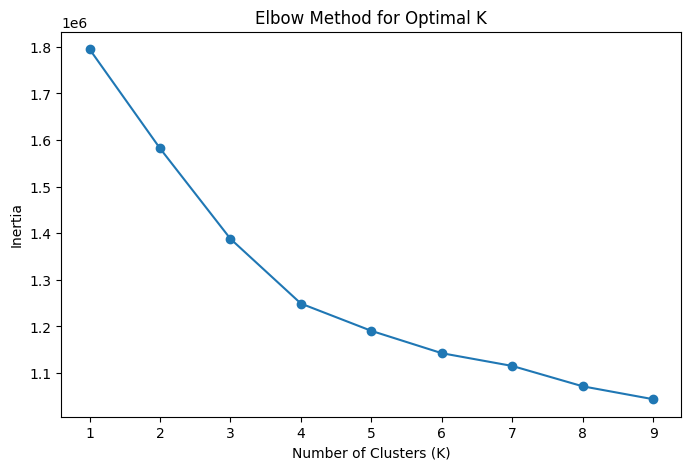

In [5]:
# ---------------------------------
# BUSCAR MEJOR NÚMERO DE CLUSTERS (ELBOW METHOD)
# ---------------------------------

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Lista para guardar la inercia (error)
inertia = []

# Probar diferentes valores de Klusters
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# ---------------------------------
# VISUALIZACIÓN DEL MÉTODO DEL CODO
# ---------------------------------

plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [6]:
#eliges 5 clusters
#asignas cada Airbnb a un grupo
kmeans = KMeans(n_clusters=5, random_state=42)
l["cluster"] = kmeans.fit_predict(X_scaled)
#Calculas el promedio de cada cluster.
summary = l.groupby("cluster").mean()
print(summary)

                   listing_id  photos_count     guests  bedrooms      beds  \
cluster                                                                      
0        320805524145435.9375      45.21916  10.115486  4.613298  7.223535   
1          6604419649413823.0     23.900045   3.700245   1.44266  2.247534   
2          6411221047016526.0     28.503692   3.777434  1.542783  2.309786   
3          6873889291136856.0     24.480798    4.66653  1.826568  3.036354   
4          2269375442282457.5     37.807302   7.183973  3.234614  4.966240   

            baths  amenities_count  min_nights  cleaning_fee  extra_guest_fee  \
cluster                                                                         
0        3.538058        46.296588    3.547244    240.189414         0.793963   
1        1.104666        33.046436    5.335546     32.160893         1.451747   
2        1.169300        38.343661     3.28598     40.198244         1.221379   
3        1.280853        28.936039    4.839825  

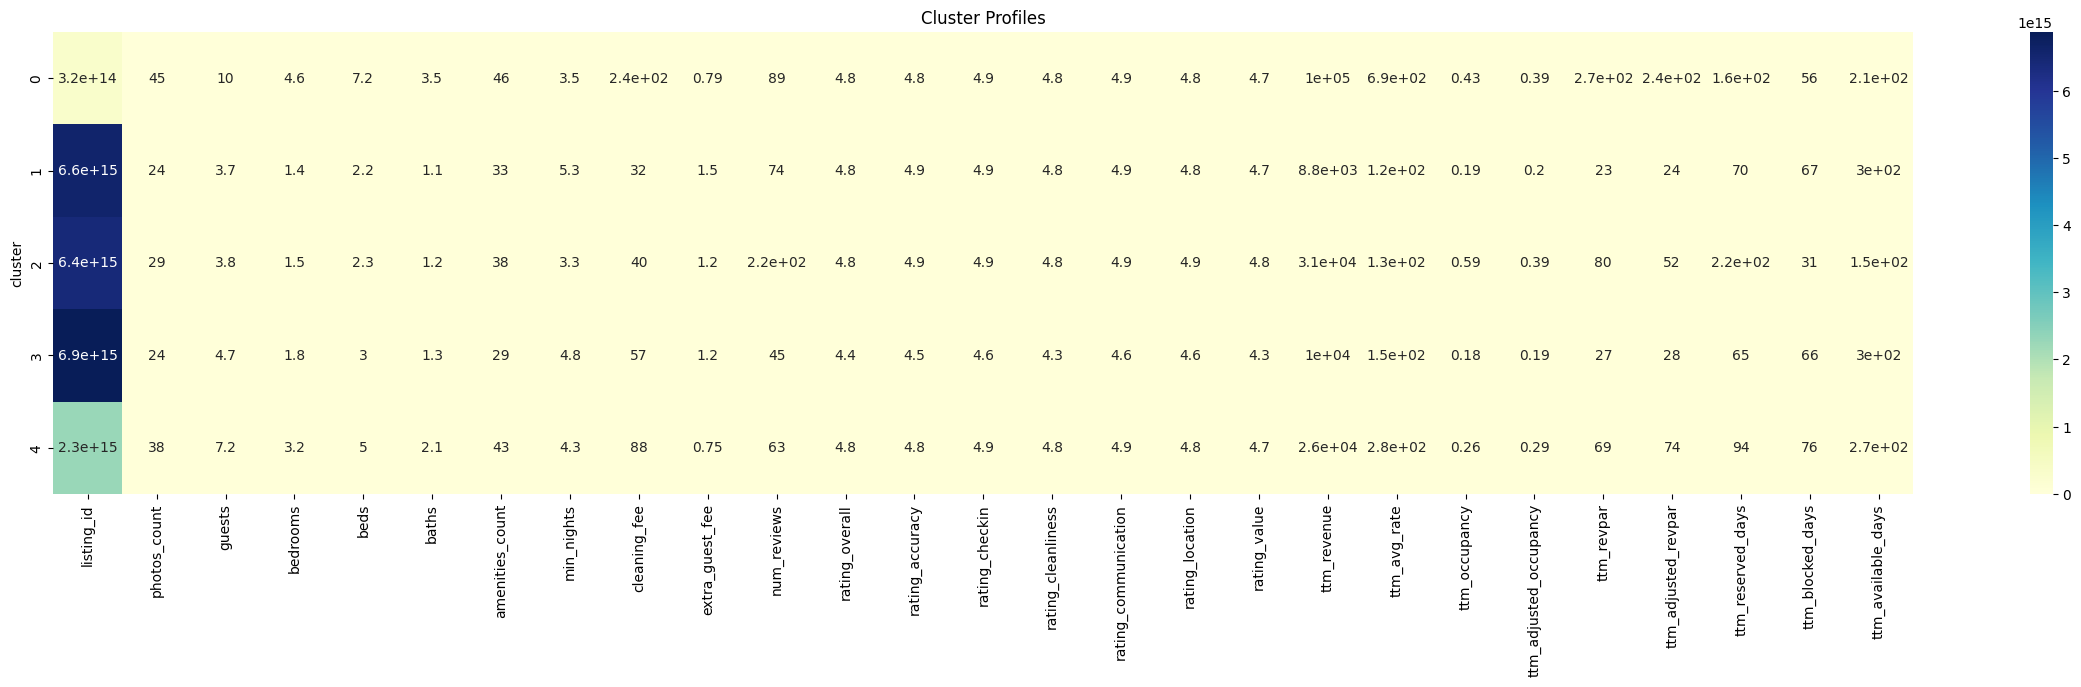

In [7]:
# eliminar columnas no numéricas
summary1 = l.groupby("cluster").mean(numeric_only=True)
summary1 = summary1.astype(float)
plt.figure(figsize=(30,6))
sns.heatmap(summary1, cmap="YlGnBu", annot=True)
plt.title("Cluster Profiles")
plt.show()
#Transformas los clusters en imagen.
#Cada fila = cluster
#Cada columna = variable
#Color = valor medio

In [8]:
l2 = df_listings.select_dtypes(include="number").copy()

derived_vars = [
    'ttm_occupancy',
    'ttm_adjusted_occupancy',
    'ttm_revpar',
    'ttm_adjusted_revpar',
    'ttm_reserved_days',
    'ttm_blocked_days',
    'ttm_available_days'
]

l2 = l2.drop(columns=derived_vars, errors='ignore')

l2 = l2.apply(pd.to_numeric, errors='coerce')
l2 = l2.dropna()

print(l2)

       listing_id  photos_count  guests  bedrooms  beds  baths  \
0          121902            77       6         3   4.0    1.0   
2          805361            34       5         2   4.0    1.0   
3          853827            70      16        12  15.0    6.0   
5          997955            42       6         2   3.0    1.5   
6         1149100            55       6         3   3.0    2.0   
...           ...           ...     ...       ...   ...    ...   
95890    45846495            16       4         2   2.0    1.0   
95891    45877504            23       5         2   4.0    1.0   
95893    46309704            33       6         2   4.0    2.0   
95894    46488808            10       2         1   1.0    1.0   
95896    46637115            15       6         3   5.0    2.0   

       amenities_count  min_nights  cleaning_fee  extra_guest_fee  \
0                   75           7             0                0   
2                   44           3           104                0   


In [9]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()
X_scaled2 = scaler2.fit_transform(l2) #Todas las variables en la misma escala.
pd.DataFrame(X_scaled2, columns=l2.columns).head()  # Solo visualizas cómo quedaron los datos escalados.

,listing_id,photos_count,guests,bedrooms,beds,baths,amenities_count,min_nights,cleaning_fee,extra_guest_fee,num_reviews,rating_overall,rating_accuracy,rating_checkin,rating_cleanliness,rating_communication,rating_location,rating_value,ttm_revenue,ttm_avg_rate
0,-0.091279,2.988392,0.600187,0.979791,0.557809,-0.496764,2.873103,0.096341,-0.460969,-0.169398,-0.748176,1.125515,0.989868,0.812042,0.616893,0.746395,0.505811,1.379798,0.123392,1.322329
1,-0.091279,0.352783,0.170767,0.083057,0.557809,-0.496764,0.580855,-0.055630,0.439561,-0.169398,-0.655472,-0.034511,-0.069899,-2.186442,0.218873,0.145229,0.505811,0.031169,0.086108,1.090143
2,-0.091279,2.559339,4.894386,9.050400,6.428842,5.840533,-1.341676,-0.055630,-0.460969,-0.169398,-0.384489,0.400499,0.459984,-0.387351,0.218873,-0.455936,-1.090003,0.480712,2.427078,3.033629
3,-0.091279,0.843129,0.600187,0.083057,0.024079,0.136966,0.211137,-0.055630,0.240405,-0.169398,0.456985,0.448833,0.459984,0.212345,0.218873,0.746395,1.037750,0.480712,0.194836,-0.395113
4,-0.091279,1.639941,0.600187,0.979791,0.024079,0.770695,0.802685,-0.131616,0.491514,-0.169398,-0.648340,-0.856195,-1.129666,-2.186442,-0.577166,-1.057102,-2.153880,-0.867917,0.013691,-0.030249


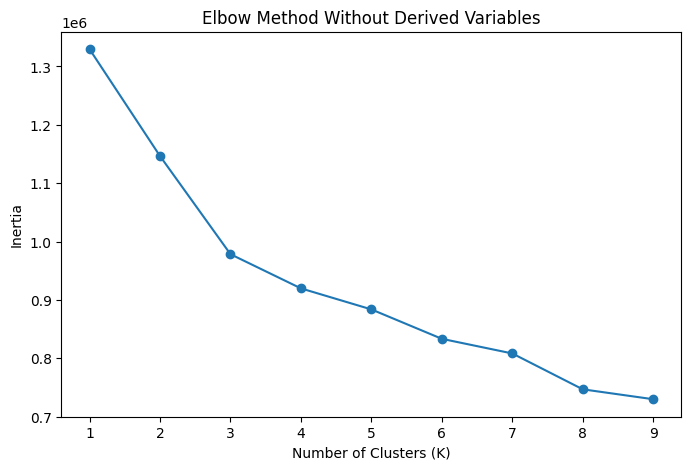

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia2 = []

for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled2)
    inertia2.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia2, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method Without Derived Variables')
plt.show()

In [11]:
#eliges 5 clusters
#asignas cada Airbnb a un grupo
kmeans = KMeans(n_clusters=5, random_state=42)
l2["cluster"] = kmeans.fit_predict(X_scaled)
#Calculas el promedio de cada cluster.
summary = l2.groupby("cluster").mean()
print(summary)

                   listing_id  photos_count     guests  bedrooms      beds  \
cluster                                                                      
0        320805524145435.9375      45.21916  10.115486  4.613298  7.223535   
1          6604419649413823.0     23.900045   3.700245   1.44266  2.247534   
2          6411221047016526.0     28.503692   3.777434  1.542783  2.309786   
3          6873889291136856.0     24.480798    4.66653  1.826568  3.036354   
4          2269375442282457.5     37.807302   7.183973  3.234614  4.966240   

            baths  amenities_count  min_nights  cleaning_fee  extra_guest_fee  \
cluster                                                                         
0        3.538058        46.296588    3.547244    240.189414         0.793963   
1        1.104666        33.046436    5.335546     32.160893         1.451747   
2        1.169300        38.343661     3.28598     40.198244         1.221379   
3        1.280853        28.936039    4.839825  

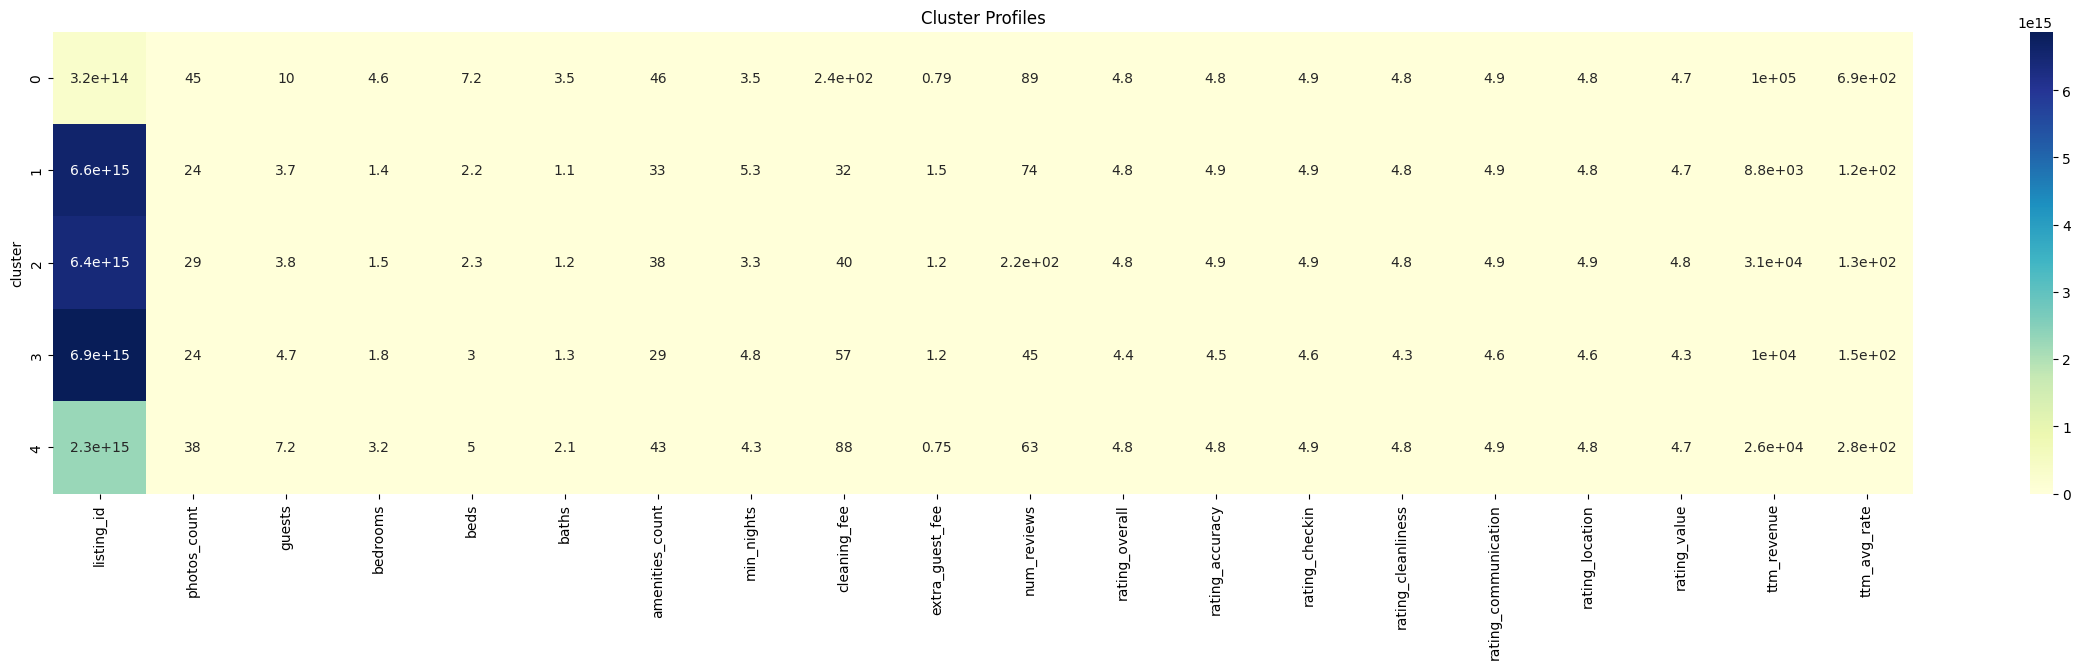

In [12]:
summary_2 = l2.groupby("cluster").mean(numeric_only=True)
summary_2 = summary_2.astype(float)
plt.figure(figsize=(30,6))
sns.heatmap(summary_2, cmap="YlGnBu", annot=True)
plt.title("Cluster Profiles")
plt.show()
#Transformas los clusters en imagen.
#Cada fila = cluster
#Cada columna = variable
#Color = valor medio

In [ ]:
kmeans2 = KMeans(n_clusters=5, random_state=42)

l["cluster"] = kmeans.fit_predict(X_scaled2)
print("Inertia 1:", kmeans.inertia_)

l2["cluster"] = kmeans2.fit_predict(X_scaled2)
print("Inertia 2:", kmeans2.inertia_)

Inertia 1: {kmeans.inertia_:.15f}
Inertia 2: {kmeans2.inertia_:.15f}


In [17]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, l["cluster"])

print("Silhouette Score:", score)

score2 = silhouette_score(X_scaled2, l2["cluster"])

print("Silhouette Score:", score2)

Silhouette Score: 0.09936505601374046
Silhouette Score: 0.12417671805488649
